## 신경망

* 입력층, 출력층, 은닉층
* 더 간결한 형태의 식
$$
y = h(b + w_1x_1 + w_2x_2)
$$
$$
h(x) =
\begin{cases}
0 & (x \le 0) \\
1 & (x > 0)
\end{cases}
$$

### 활성화 함수
* 입력 신호의 총합을 출력 신호로 변환하는 함수
* 입력 신호의 총합이 활성화를 일으키는지를 정하는 역할
* 가중치가 곱해진 입력 신호의 총합을 계산하고, 그 합을 활성화 함수에 입력해 결과를 내는 2단계로 처리
$$a = b + w_1x_1 + w_2x_2$$
$$y=h(a)$$

In [2]:
# 계단 함수
def step_function(x):
    if x > 0:
        return 1
    else:
        return 0

* 단순하지만 인수 x는 실수(부동소수점)만을 받음 -> 넘파이 배열을 인수로 넣을 수 없음

In [6]:
import numpy as np

def step_function(x):
    y = x > 0
    return y.astype(int)

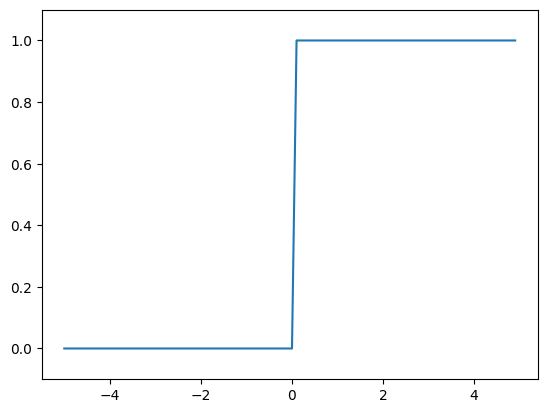

In [5]:
# 계단 함수 그래프
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1) # y축 범위 지정
plt.show()

In [7]:
# 시그모이드 함수
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.array([-1.0, 1.0, 2.0])
print(sigmoid(x))

[0.26894142 0.73105858 0.88079708]


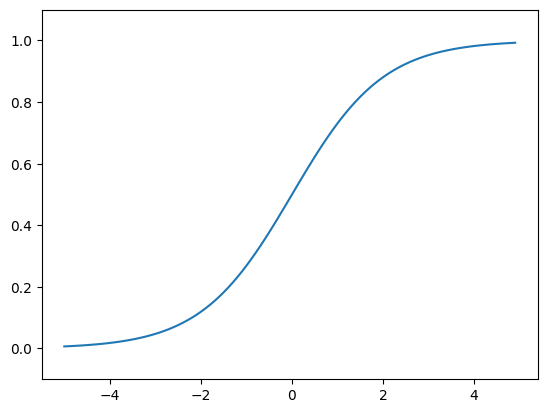

In [8]:
# 시그모이드 함수 그래프
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

#### ReLU 함수

* 입력이 0이 넘으면 그 입력을 그대로 출력, 0 이하이면 0을 출력
$$
h(x) =
\begin{cases}
x & (x > 0) \\
0 & (x \le 0)
\end{cases}
$$

In [1]:
# ReLU 함수
def relu(x):
    return np.maximum(0, x)

### 다차원 배열

In [2]:
import numpy as np

A = np.array([1, 2, 3, 4])
print(A)
print(np.ndim(A))
print(A.shape)
print(A.shape[0])

[1 2 3 4]
1
(4,)
4


In [3]:
B = np.array([[1, 2], [3, 4], [5, 6]])
print(B)
print(np.ndim(B))
print(B.shape)

[[1 2]
 [3 4]
 [5 6]]
2
(3, 2)


In [4]:
# 내적
A = np.array([[1, 2], [3, 4]])
print(A.shape)
B = np.array([[5, 6], [7, 8]])
print(B.shape)
print(np.dot(A, B))

(2, 2)
(2, 2)
[[19 22]
 [43 50]]


* np.dot()은 넘파이 배열 2개를 인수로 받아 내적을 반환
* np.dot(A, B)와 np.dot(B, A)는 다를 수 있음

In [5]:
A = np.array([[1, 2, 3], [4, 5, 6]])
print(A.shape)
B = np.array([[1, 2], [3, 4], [5, 6]])
print(B.shape)
print(np.dot(A, B))

(2, 3)
(3, 2)
[[22 28]
 [49 64]]


In [7]:
C = np.array([[1, 2], [3, 4]])
print(C.shape)
print(A.shape)
print(np.dot(A, C))

(2, 2)
(2, 3)


ValueError: shapes (2,3) and (2,2) not aligned: 3 (dim 1) != 2 (dim 0)

* 2 X 3 행렬과 2 X 2 행렬은 계산 시 오류 발생

In [11]:
A = np.array([[1, 2], [3, 4], [5, 6]])
print(A.shape)
B = np.array([7, 8])
print(B.shape)
print(A @ B)
print(np.dot(A, B))

(3, 2)
(2,)
[23 53 83]
[23 53 83]


In [12]:
# 신경망의 내적
X = np.array([1, 2])
print(X.shape)
W = np.array([[1, 3, 5], [2, 4, 6]])
print(W)
print(W.shape)
Y = np.dot(X, W)
print(Y)

(2,)
[[1 3 5]
 [2 4 6]]
(2, 3)
[ 5 11 17]


### 3층 신경망 구현

$$W^{(1)}_{12}$$
* (1): 1층의 가중치
* 1: 다음 층의 1번째 뉴런
* 2: 앞 층의 2번째 뉴런


$$a^{(1)}_{1} = W^{(1)}_{11}x_1 + W^{(1)}_{12}x_2 + b^{(1)}_1$$
* 행렬의 내적을 이용해 간소화 하면 아래와 같이 나타낼 수 있음

$$A^{(1)} = XW^{(1)} + B^{(1)}

$$
A^{(1)} =
\begin{pmatrix}
a^{(1)}_1 & a^{(1)}_2 & a^{(1)}_3
\end{pmatrix}
\\
B^{(1)} =
\begin{pmatrix}
b^{(1)}_1 & b^{(1)}_2 & b^{(1)}_3
\end{pmatrix}
\\
X =
\begin{pmatrix}
x_1 & x_2
\end{pmatrix}
\\
W^{(1)} =
\begin{pmatrix}
w^{(1)}_{11} & w^{(1)}_{12} & w^{(1)}_{13} \\
w^{(1)}_{21} & w^{(1)}_{22} & w^{(1)}_{23}
\end{pmatrix}
$$

In [18]:
# 1층
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])

print(W1.shape)
print(X.shape)
print(B1.shape)

A1 = np.dot(X, W1) + B1
print(A1)

Z1 = sigmoid(A1)
print(Z1)

(2, 3)
(2,)
(3,)
[0.3 0.7 1.1]
[0.57444252 0.66818777 0.75026011]


In [21]:
# 2층
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

print(Z1.shape)
print(W2.shape)
print(B2.shape)

A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)

print(A2)
print(Z2)

(3,)
(3, 2)
(2,)
[0.51615984 1.21402696]
[0.62624937 0.7710107 ]


In [22]:
# 출력층
def identity_function(X):
    return X

W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3)

print(Y)

[0.31682708 0.69627909]


In [24]:
# 구현 정리
def init_network():
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])

    return network

def forward(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identity_function(a3)

    return Y

if __name__ == "__main__":
    network = init_network()
    x = np.array([1.0, 0.5])
    y = forward(network, x)
    print(y)

[0.31682708 0.69627909]


### 출력층 설계

* 일반적으로 회귀에는 항등 함수, 분류에는 소프트맥스 함수를 사용
    * 회귀: 연속적인 실수 값을 예측 -> 값 범위 제한 없는 항등 함수
    * 분류: 클래스 확률 예측 -> 확률 분포 생성

#### 소프트맥스 함수
$$
y_k = \frac{\exp(a_k)}{\sum_{i=1}^{n} \exp(a_i)}
$$

* n: 출력층의 뉴런 수
* $y_k$: k번째 출력
* $a_k$: 입력 신호

In [6]:
a = np.array([0.3, 2.9, 4.0])
exp_a = np.exp(a)
print(exp_a)

sum_exp_a = np.sum(exp_a)
print(sum_exp_a)

y = exp_a / sum_exp_a
print(y)

[ 1.34985881 18.17414537 54.59815003]
74.1221542101633
[0.01821127 0.24519181 0.73659691]


In [7]:
def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

* 오버플로 발생 가능
* 오버플로: 표현할 수 있는 수의 범위가 한정되어 너무 큰 값은 표현할 수 없는 문제


$$
y_k = \frac{\exp(a_k)}{\sum_{i=1}^{n} \exp(a_i)} = \frac{C\exp(a_k)}{C\sum_{i=1}^{n} \exp(a_i)} \\
= \frac{\exp(a_k + \log{C})}{\sum_{i=1}^{n} \exp(a_i + \log{C})} \\
= \frac{\exp(a_k + C')}{\sum_{i=1}^{n} \exp(a_i + C')}
$$

* 임의의 정수 C를 곱한 후, exp() 안으로 넣어 $\log{C}$로 만든 후 C'으로 변경
* 보통 입력 신호 중 최댓값을 이용하는 것이 일반적

In [9]:
a = np.array([1010, 1000, 990])
print(np.exp(a) / np.sum(np.exp(a)))

c = np.max(a)
print(a - c)

print(np.exp(a - c) / np.sum(np.exp(a - c)))

[nan nan nan]
[  0 -10 -20]
[9.99954600e-01 4.53978686e-05 2.06106005e-09]


C:\Users\기현\AppData\Local\Temp\ipykernel_13904\4087389916.py:2: RuntimeWarning: overflow encountered in exp
  print(np.exp(a) / np.sum(np.exp(a)))
C:\Users\기현\AppData\Local\Temp\ipykernel_13904\4087389916.py:2: RuntimeWarning: invalid value encountered in divide
  print(np.exp(a) / np.sum(np.exp(a)))


In [18]:
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

In [12]:
a = np.array([0.3, 2.9, 4.0])
y = softmax(a)
print(y)
print(np.sum(y))

[0.01821127 0.24519181 0.73659691]
1.0


* 소프트맥스 함수의 출력은 0에서 1.0 사이의 실수
* 출력의 총합은 1 -> 확률로 해석 가능
* 소프트맥스 함수는 단조증가 함수라 출력이 가장 큰 뉴런의 위치는 달라지지 않음 -> 현업에서 생략하는 것이 일반적

### 손글씨 숫자 인식

#### MNIST 데이터셋
* 손글씨 숫자 이미지 집합
* 0~9까지의 숫자 이미지로 구성
* 훈련 이미지 60,000장, 시험 이미지 10,000장
* 이미지 데이터는 28 x 28 크기의 회색조 이미지(1채널)이며 각 픽셀은 0~255 사이의 값을 가짐
* 각 이미지에는 그 이미지가 실제 의미하는 숫자가 레이블로 붙어있음

In [1]:
import sys, os
sys.path.append(os.path.pardir) # 부모 디렉터리의 파일을 가져올 수 있도록 설정
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=True)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [12]:
import sys, os
sys.path.append(os.path.pardir)
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image

def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

img = x_train[0]
label = t_train[0]
print(label)

print(img.shape)
img = img.reshape(28, 28)
print(img.shape)

img_show(img)

5
(784,)
(28, 28)


In [22]:
def get_data():
    (x_train, t_train), (x_test, t_test) = \
        load_mnist(flatten=True, normalize=True, one_hot_label=False)
    
    return x_test, t_test

def init_network():
    with open("sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)

    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y

In [23]:
x, t = get_data()
network = init_network()

accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    if p == t[i]:
        accuracy_cnt += 1
    
print(f"Accuracy: {float(accuracy_cnt) / len(x)}")

C:\Users\기현\AppData\Local\Temp\ipykernel_11928\2961110660.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  network = pickle.load(f)


Accuracy: 0.9352


#### 배치처리

In [24]:
x, _ = get_data()
network = init_network()
W1, W2, W3 = network['W1'], network['W2'], network['W3']

print(x.shape)
print(x[0].shape)
print(W1.shape)
print(W2.shape)
print(W3.shape)

(10000, 784)
(784,)
(784, 50)
(50, 100)
(100, 10)


C:\Users\기현\AppData\Local\Temp\ipykernel_11928\2961110660.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  network = pickle.load(f)


* 출력 데이터의 형상은 100 x 10 -> 100장 분량의 입력 데이터의 결과가 한 번에 출력됨
* 배치: 하나로 묶은 입력 데이터

In [25]:
x, t = get_data()
network = init_network()

accuracy_cnt = 0
batch_size = 100

for i in range(0, len(x), batch_size):
    x_batch = x[i:i + batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i + batch_size])
    
print(f"Accuracy: {float(accuracy_cnt) / len(x)}")

Accuracy: 0.9352


C:\Users\기현\AppData\Local\Temp\ipykernel_11928\2961110660.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  network = pickle.load(f)


In [26]:
x = np.array([[0.1, 0.8, 0.1], [0.3, 0.1, 0.6], [0.2, 0.5, 0.3], [0.8, 0.1, 0.1]])
y = np.argmax(x, axis=1)
print(y)

[1 2 1 0]
